# 🛒 LankaMart Sales Analysis Project

**👤 Name:** K. Nikeshala Diwyanjali  
**📞 Phone:** 0762503808  
**🎓 Program:** AI/ML Ignition Program (Batch 01)


## 📦 1. Import Libraries

These libraries are used for data handling, analysis, and visualization in this project.

In [23]:
#Import numpy, pandas, and matplotlib -

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 



## 📊 2. Load Dataset

Load the dataset to start the analysis.

In [ ]:
# Read the dataset -

df = pd.read_csv ('supermarket_sales_srilanka_1500.csv')

# Display the first few rows of the dataset -

df.head(5)


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Total,Date,Time,Payment,Rating
0,SLM-100001,Galle,Galle,Member,Male,Household,584.33,5,2629.49,2026-02-15,21:51,Cash,6.8
1,SLM-100002,Kandy,Kandy,Member,Male,Household,3170.80,3,9131.90,2026-01-14,15:55,Cash,7.7
2,SLM-100003,Galle,Galle,Normal,Male,Beverages,925.68,6,4998.67,2026-02-16,19:45,Card,6.7
3,SLM-100004,Colombo,Colombo,Member,Female,Personal Care,2521.37,6,17851.30,2026-02-17,13:40,Cash,8.0
4,SLM-100005,Kandy,Kandy,Member,Male,Household,1801.89,6,10378.89,2026-02-16,18:37,eZ Cash,7.9


## 📈 3. Data Overview

This step helps us understand the dataset size, structure, and summary statistics.

In [ ]:
# Check the shape, info, and summary statistics of the dataset -

df.shape
df.info() 
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Invoice_ID        1500 non-null   object 
 1   Branch            1500 non-null   object 
 2   City              1500 non-null   object 
 3   Customer_Type     1500 non-null   object 
 4   Gender            1500 non-null   object 
 5   Product_Category  1500 non-null   object 
 6   Unit_Price        1500 non-null   float64
 7   Quantity          1500 non-null   int64  
 8   Total             1500 non-null   float64
 9   Date              1500 non-null   object 
 10  Time              1500 non-null   object 
 11  Payment           1494 non-null   object 
 12  Rating            1492 non-null   float64
dtypes: float64(3), int64(1), object(9)
memory usage: 152.5+ KB


,Unit_Price,Quantity,Total,Rating
count,1500.000000,1500.000000,1500.000000,1492.000000
mean,1710.407593,3.917333,7126.569253,7.152547
std,1693.475187,1.794244,8727.972507,1.287150
min,121.380000,1.000000,137.050000,3.100000
25%,601.970000,2.000000,1841.367500,6.200000
50%,1264.445000,4.000000,4183.125000,7.200000
75%,2061.880000,5.000000,8921.992500,8.000000
max,9463.720000,8.000000,71312.050000,10.000000


## 🧹 4. Data Cleaning

We clean missing values and fix text fields to improve data quality.

In [ ]:
# Strip leading and trailing whitespace from the "Product_Category" column -

df["Product_Category"] = df["Product_Category"].str.strip()

# Fill missing values in the "Payment" column with "Unknown" -

df["Payment"] = df["Payment"].fillna("Unknown")

# Fill missing values in the "Rating" column with the mean rating -

df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

## 💰 5. Total Sales

This represents the total revenue generated from the dataset.

In [ ]:
# Calculate total sales -

total_sales = df["Total"].sum()
total_sales

np.float64(10689853.879999999)

## 🏢 6. Sales by Branch

This analysis identifies which branch contributes the most to total sales.

In [9]:
# Calculate total sales by branch using groupby and sort the results in descending order -

branch_sales = df.groupby("Branch")["Total"].sum().sort_values(ascending=False)
branch_sales

Branch
Colombo    5507914.09
Kandy      2942373.76
Galle      2239566.03
Name: Total, dtype: float64

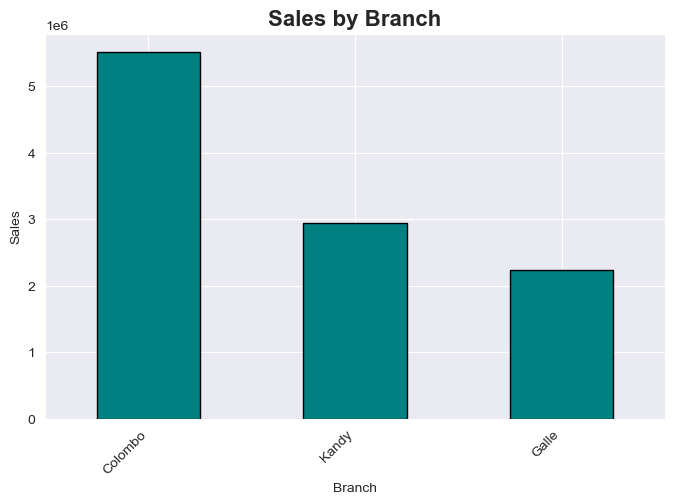

In [46]:
# Visualize sales by branch using a bar chart -
sns.set_style("darkgrid")

plt.figure(figsize=(8, 5))

branch_sales.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Sales by Branch", fontsize=16, fontweight="bold")
plt.xlabel("Branch")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.show()


**Finding:** ________ branch generates the highest revenue, while ________ contributes the least.

## 🛍️ 7. Sales by Product Category

This analysis identifies which product categories generate the highest revenue.

In [11]:
# Calculate total sales by product category using groupby and sort the results in descending order -

category_sales = df.groupby("Product_Category")["Total"].sum().sort_values(ascending=False)
category_sales

Product_Category
Electronics      4010868.47
Food             2500763.52
Household        2068873.92
Personal Care    1522994.54
Beverages         586353.43
Name: Total, dtype: float64

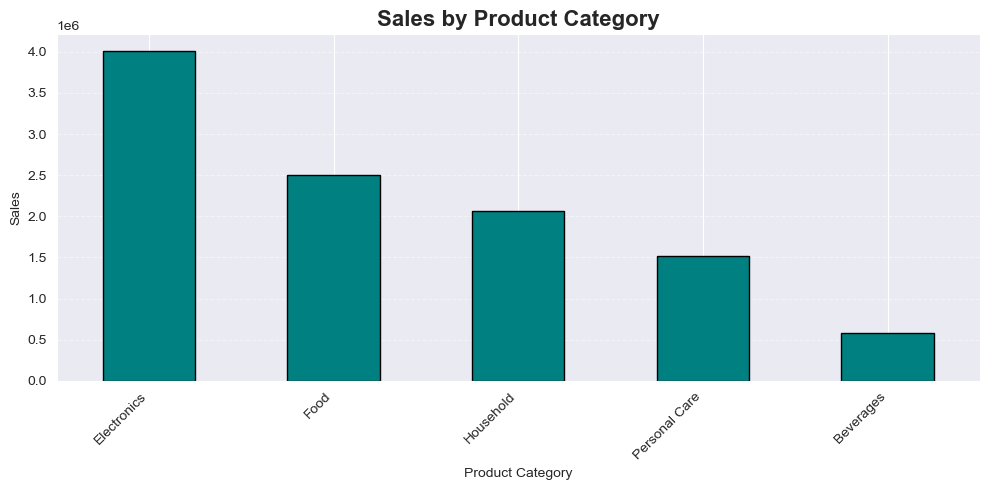

In [44]:
# Visualize sales by product category using a bar chart -

sns.set_style("darkgrid")

plt.figure(figsize=(10, 5))

category_sales.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)


plt.title("Sales by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()


plt.show()



**Finding:** ________ dominates sales, while ________ generate the least revenue.

## ⏰ 8. Peak Shopping Hours

This analysis examines customer activity across different hours of the day to identify peak shopping times.

In [13]:
# Extract the hour from the "Time" column and create a new "Hour" column -

df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M").dt.hour

# Calculate total sales by hour using groupby and sort the results in descending order -

hourly_sales = df.groupby("Hour")["Total"].sum()
hourly_sales

Hour
8      264822.68
9      348152.57
10     484427.56
11     466727.42
12     717179.35
13     817923.30
14    1163419.25
15    1077544.36
16    1057953.56
17    1278969.70
18    1141597.45
19     790790.86
20     595489.87
21     484855.95
Name: Total, dtype: float64

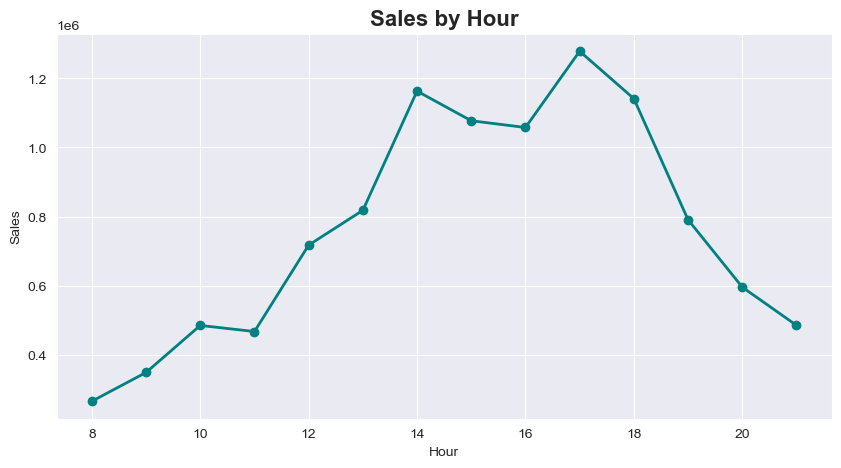

In [47]:
# Visualize sales by hour using a line chart with markers -

# nice style
sns.set_style("darkgrid")

# figure size (important for looks)
plt.figure(figsize=(10, 5))

# plot with styling
hourly_sales.plot(
    marker="o",
    linewidth=2,
    color="teal"
)

# title + labels
plt.title("Sales by Hour", fontsize=16, fontweight="bold")
plt.xlabel("Hour")
plt.ylabel("Sales")

plt.show()


**Finding:** Peak shopping occurs in the afternoon and evening (around 14:00–18:00)

## 💳 9. Payment Analysis

This analysis explores customer payment preferences to understand the most commonly used payment methods.

In [15]:
# Calculate the number of transactions for each payment method using value_counts -

payment_counts = df["Payment"].value_counts()
payment_counts

Payment
Cash       683
Card       523
eZ Cash    288
Unknown      6
Name: count, dtype: int64

**Finding:** Cash is the most used payment method, followed by card payments.

## ⭐ 10. Customer Satisfaction

This analysis evaluates customer satisfaction by comparing average ratings across branches.

In [16]:
# Calculate the average rating for each branch using groupby and sort the results in descending order -

branch_rating = df.groupby("Branch")["Rating"].mean().sort_values(ascending=False)
branch_rating

Branch
Kandy      7.216277
Colombo    7.127929
Galle      7.117763
Name: Rating, dtype: float64

**Finding:** Kandy has slightly higher customer satisfaction compared to other branches.

## 🔍 11. Advanced Analysis

Advanced data analysis techniques are applied to uncover deeper insights from the dataset.

### Profit Estimation
Estimate profit based on 20% margin assumption.

In [17]:
# Calculate the estimated profit for each transaction (assuming a profit margin of 20%) and add it as a new column -

df["Estimated_Profit"] = df["Total"] * 0.2

# Calculate total estimated profit by branch using groupby and sort the results in descending order -

df.groupby("Branch")["Estimated_Profit"].sum().sort_values(ascending=False)

Branch
Colombo    1101582.818
Kandy       588474.752
Galle       447913.206
Name: Estimated_Profit, dtype: float64

### Member vs Normal Customers
Compare spending behavior.

In [18]:
# Calculate total sales, average sales, and transaction count for each customer type using groupby and agg -

df.groupby("Customer_Type")["Total"].agg(["sum","mean","count"])


,sum,mean,count
Customer_Type,,,
Member,5189272.02,7477.337205,694
Normal,5500581.86,6824.543251,806


**Finding:** ________ spend slightly more on average, but ________ contribute higher total sales.

### Top Categories per Branch

In [19]:
# Calculate total sales by branch and product category using groupby and sort the results in descending order, then display the top 3 categories for each branch -

category_totals = df.groupby(["Branch","Product_Category"])["Total"].sum().reset_index()
category_totals = category_totals.sort_values(["Branch","Total"], ascending=[True,False])
category_totals.groupby("Branch").head(3)


,Branch,Product_Category,Total
1,Colombo,Electronics,2186796.11
2,Colombo,Food,1355859.09
3,Colombo,Household,973794.46
6,Galle,Electronics,712621.91
8,Galle,Household,528418.86
7,Galle,Food,511215.98
11,Kandy,Electronics,1111450.45
12,Kandy,Food,633688.45
13,Kandy,Household,566660.60


### Peak Hour per Branch

In [20]:
# Calculate total sales by branch and hour using groupby and sort the results in descending order, then display the top 3 hours for each branch -

grouped = df.groupby(["Branch","Hour"])["Total"].sum().reset_index()
sorted_df = grouped.sort_values(["Branch","Total"], ascending=[True,False])
sorted_df.groupby("Branch").head(3)

,Branch,Hour,Total
6,Colombo,14,716945.79
7,Colombo,15,631204.41
9,Colombo,17,607513.35
23,Galle,17,379704.87
24,Galle,18,235803.86
20,Galle,14,195755.45
36,Kandy,16,340638.16
38,Kandy,18,306539.61
39,Kandy,19,302577.37


## 📌 12. Key Findings
- Colombo is the strongest performing branch with significantly higher revenue.
- Electronics is the most profitable product category.
- Peak shopping hours are in the afternoon and evening.
- Cash dominates as the preferred payment method.
- Customer satisfaction is consistent, but Kandy performs slightly better.

## 💡 13. Recommendations
- Increase stock and promotions for high-performing categories like electronics.
- Improve marketing and operational efficiency in lower-performing branches such as Galle.
- Allocate more staff during peak hours to reduce congestion and improve service.
- Enhance digital payment options to encourage non-cash transactions.
- Focus on improving customer service in branches with slightly lower ratings.